# Control Matrix Policy Analysis

Visualise control-matrix equity allocations for each return sampler.

For each sampler:
- one figure is produced,
- columns correspond to time-node counts,
- rows correspond to wealth-node counts,
- each subplot is a heatmap of equity allocation (%) over time-node x wealth-node.

In [1]:
import os
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('..')
from utils.experiment import load_experiments

RESULTS_DIR = '../Control Matrix Policy/Results'
PLOTS_DIR = './Plots'
EQUITY_INDEX = 1  # [bonds, stocks] -> stocks

os.makedirs(PLOTS_DIR, exist_ok=True)

experiments = load_experiments(results_dir=RESULTS_DIR, lazy_arrays=True)
print(f'Loaded {len(experiments)} control-matrix experiments from {RESULTS_DIR}')

Loaded 9 control-matrix experiments from ../Control Matrix Policy/Results


In [2]:
def _format_money_tick(value: float) -> str:
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    return f'${value / 1_000:.0f}k'

def _bilinear_interpolate_surface(
    surface: np.ndarray,
    x_nodes: np.ndarray,
    y_nodes: np.ndarray,
    x_target: np.ndarray,
    y_target: np.ndarray,
) -> np.ndarray:
    """Bilinearly interpolate a surface defined on (x_nodes, y_nodes)."""
    surface = np.asarray(surface, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)

    # First interpolate along wealth for each time node.
    wealth_interp = np.vstack([
        np.interp(y_target, y_nodes, surface[x_idx, :])
        for x_idx in range(len(x_nodes))
    ])

    # Then interpolate along time for each wealth location.
    out = np.zeros((len(x_target), len(y_target)), dtype=float)
    for y_idx in range(len(y_target)):
        out[:, y_idx] = np.interp(x_target, x_nodes, wealth_interp[:, y_idx])

    return out

INTERP_TIME_POINTS = 180
INTERP_WEALTH_POINTS = 180

records = []
for payload in experiments:
    cfg = payload['config']
    res = payload['result']

    # Keep only true control-matrix runs.
    if int(cfg.TIME_NODE_COUNT) <= 1 or int(cfg.WEALTH_NODE_COUNT) <= 1:
        continue

    policy = np.asarray(res.best_policy, dtype=float)
    if policy.ndim != 3 or policy.shape[2] <= EQUITY_INDEX:
        continue

    time_nodes = np.asarray(res.time_nodes, dtype=float)
    wealth_nodes = np.asarray(res.wealth_nodes, dtype=float)
    equities = policy[:, :, EQUITY_INDEX]  # shape: [time_nodes, wealth_nodes]

    records.append({
        'sampler': cfg.RETURN_SAMPLER,
        'time_count': int(cfg.TIME_NODE_COUNT),
        'wealth_count': int(cfg.WEALTH_NODE_COUNT),
        'time_nodes': time_nodes,
        'wealth_nodes': wealth_nodes,
        'equities': equities,
        'best_utility': float(res.best_utility),
    })

print(f'Usable control-matrix runs: {len(records)}')

if not records:
    raise RuntimeError('No control-matrix runs found to plot.')

# Keep the best run if duplicate (sampler, time_count, wealth_count) exists.
best_by_key = {}
for r in records:
    key = (r['sampler'], r['time_count'], r['wealth_count'])
    prev = best_by_key.get(key)
    if prev is None or r['best_utility'] > prev['best_utility']:
        best_by_key[key] = r

samplers = sorted({k[0] for k in best_by_key})
time_counts = sorted({k[1] for k in best_by_key})
wealth_counts = sorted({k[2] for k in best_by_key})

print('Samplers:', samplers)
print('Time-node counts:', time_counts)
print('Wealth-node counts:', wealth_counts)

Usable control-matrix runs: 9
Samplers: ['cholesky']
Time-node counts: [2, 3, 6, 10]
Wealth-node counts: [2, 3, 6]


C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_28288\4167341850.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


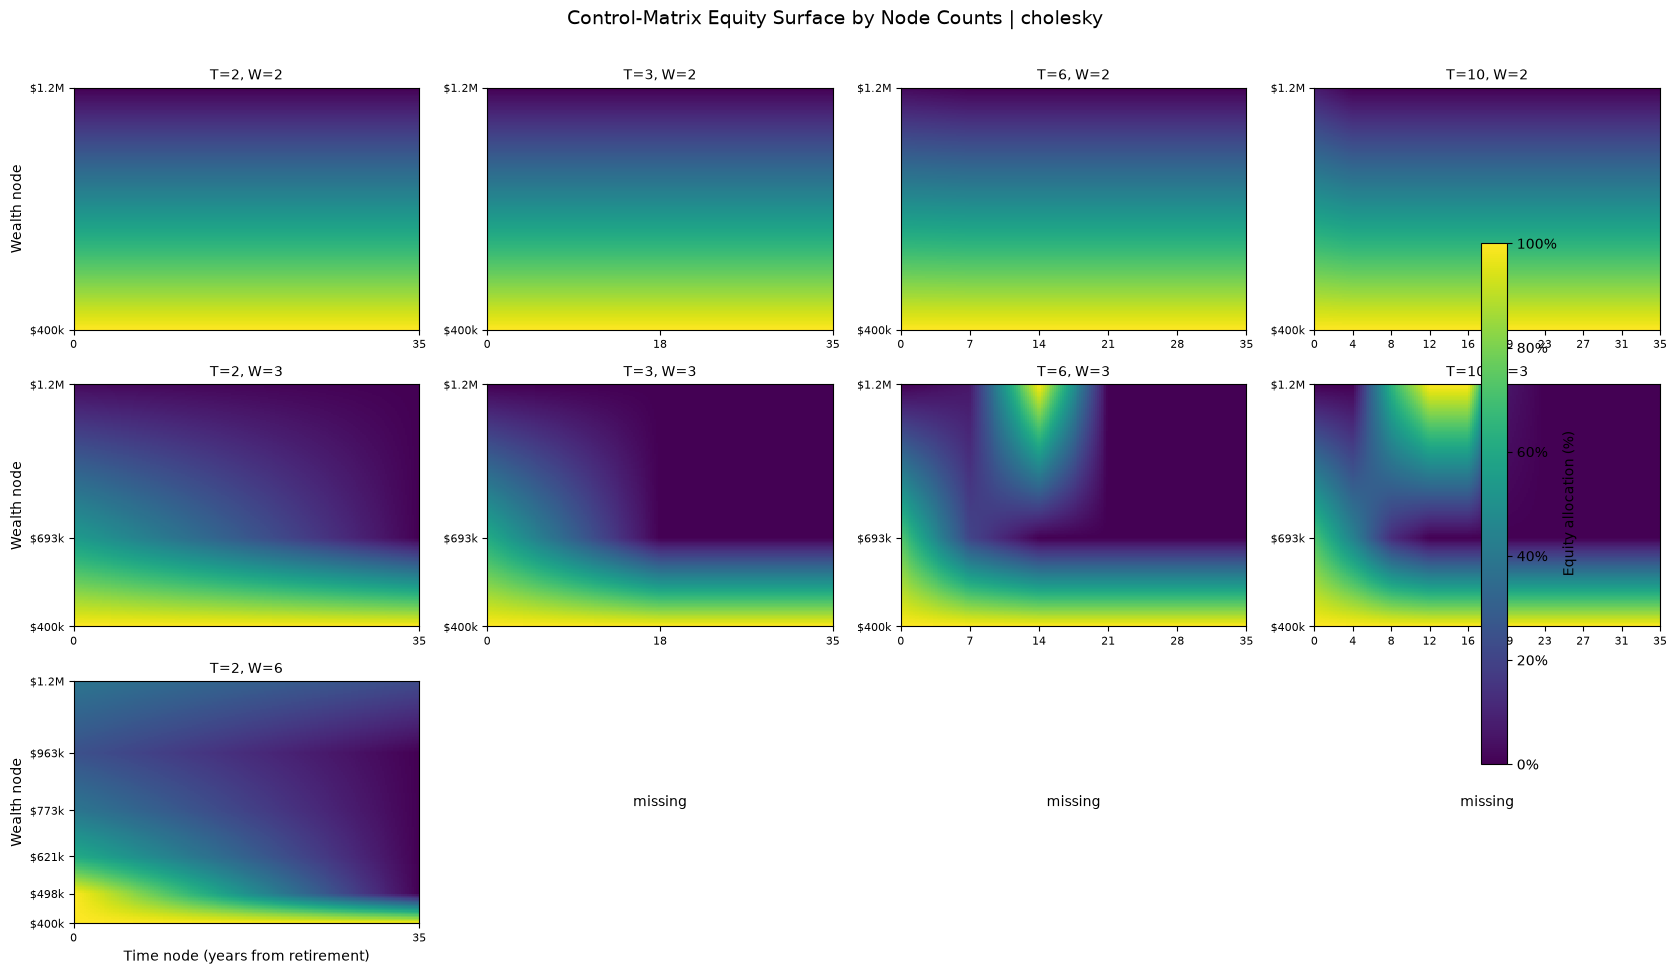

Saved: ./Plots\control_matrix_equity_surface_cholesky.png


In [3]:
for sampler in samplers:
    n_rows = len(wealth_counts)
    n_cols = len(time_counts)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(4.2 * n_cols, 3.2 * n_rows),
        squeeze=False,
    )

    image_handle = None

    for row_idx, wealth_count in enumerate(wealth_counts):
        for col_idx, time_count in enumerate(time_counts):
            ax = axes[row_idx, col_idx]
            key = (sampler, time_count, wealth_count)
            rec = best_by_key.get(key)

            if rec is None:
                ax.set_axis_off()
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax.transAxes)
                continue

            equities = rec['equities']  # [time_count, wealth_count]
            time_nodes = rec['time_nodes']
            wealth_nodes = rec['wealth_nodes']

            interp_time = np.linspace(time_nodes.min(), time_nodes.max(), INTERP_TIME_POINTS)
            interp_wealth = np.linspace(wealth_nodes.min(), wealth_nodes.max(), INTERP_WEALTH_POINTS)
            equities_interp = _bilinear_interpolate_surface(
                surface=equities,
                x_nodes=time_nodes,
                y_nodes=wealth_nodes,
                x_target=interp_time,
                y_target=interp_wealth,
            )

            image_handle = ax.pcolormesh(
                interp_time,
                interp_wealth,
                equities_interp.T,
                shading='auto',
                cmap='viridis',
                vmin=0.0,
                vmax=1.0,
            )

            ax.set_title(f'T={time_count}, W={wealth_count}', fontsize=10)

            ax.set_xticks(time_nodes)
            ax.set_xticklabels([f'{t:.0f}' for t in time_nodes], rotation=0, fontsize=8)
            ax.set_yticks(wealth_nodes)
            ax.set_yticklabels([_format_money_tick(w) for w in wealth_nodes], fontsize=8)
            ax.set_xlim(time_nodes.min(), time_nodes.max())
            ax.set_ylim(wealth_nodes.min(), wealth_nodes.max())

            if row_idx == n_rows - 1:
                ax.set_xlabel('Time node (years from retirement)')
            if col_idx == 0:
                ax.set_ylabel('Wealth node')

    if image_handle is not None:
        cbar = fig.colorbar(image_handle, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
        cbar.set_label('Equity allocation (%)')
        cbar.set_ticks(np.linspace(0, 1, 6))
        cbar.set_ticklabels([f'{int(x * 100)}%' for x in np.linspace(0, 1, 6)])

    fig.suptitle(f'Control-Matrix Equity Surface by Node Counts | {sampler}', fontsize=14, y=1.01)
    fig.tight_layout()

    out_file = os.path.join(PLOTS_DIR, f'control_matrix_equity_surface_{sampler}.png')
    fig.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_file}')

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_28288\272058908.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


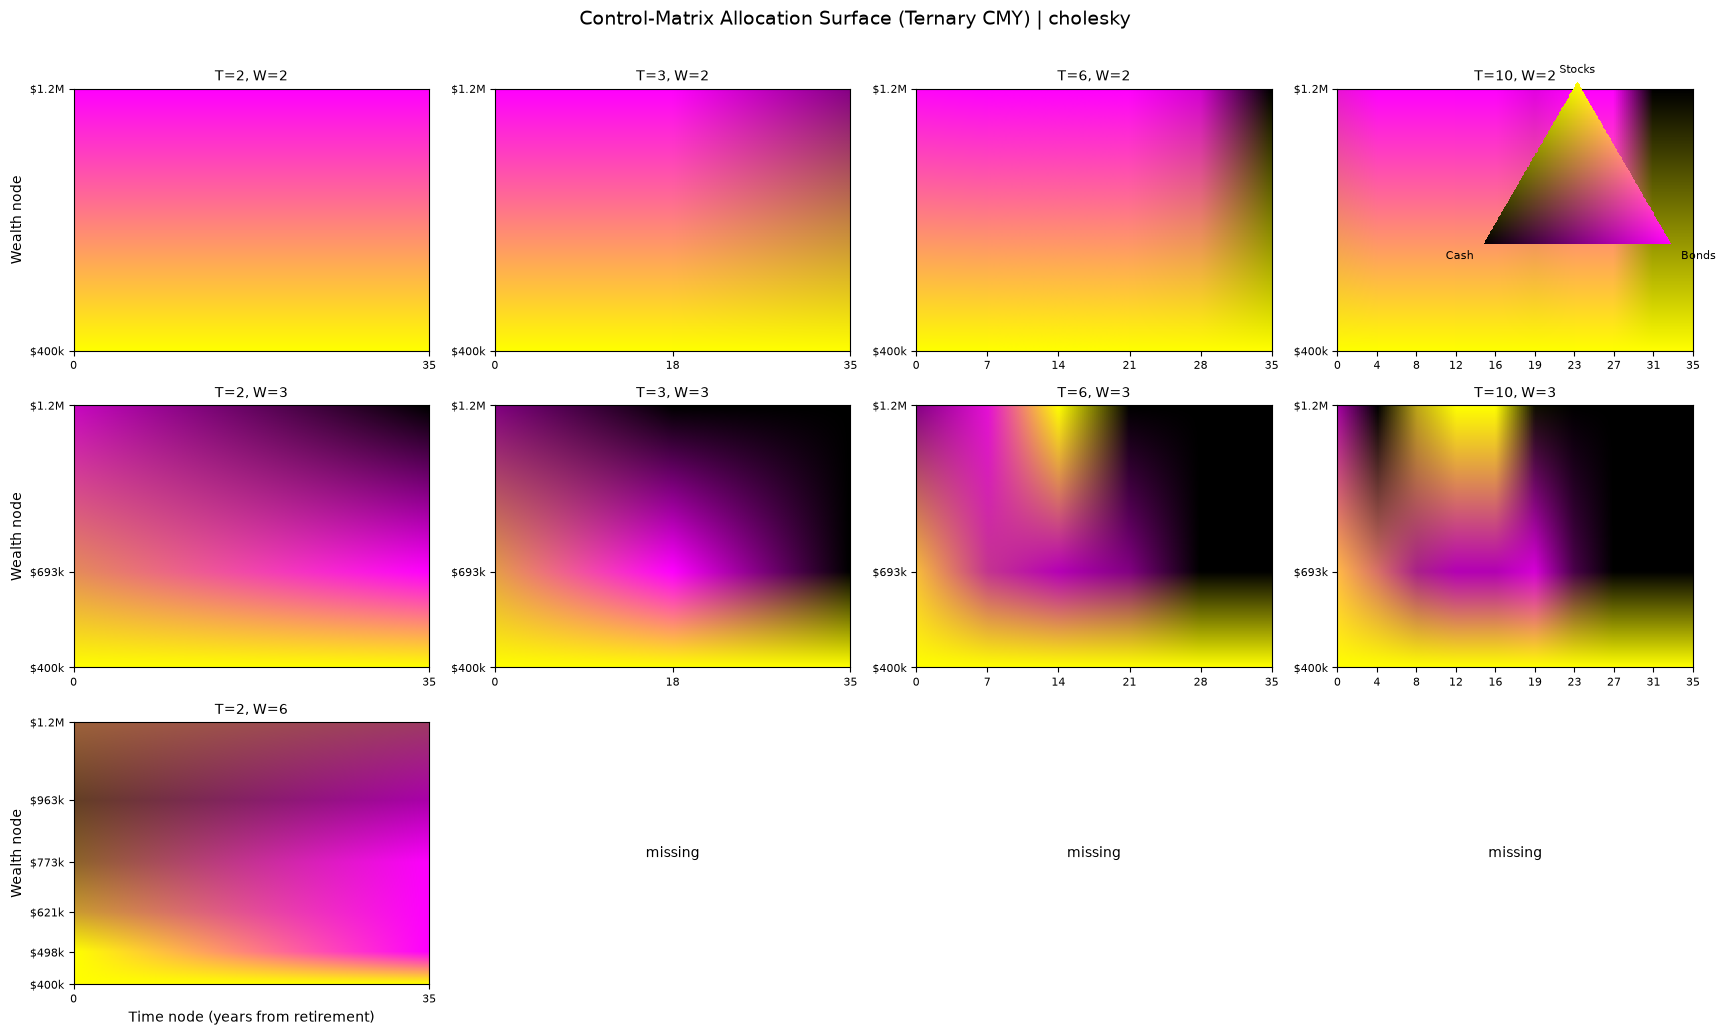

Saved: ./Plots\control_matrix_allocation_ternary_cholesky.png


In [4]:
# Ternary RGB view: show Cash/Bonds/Stocks simultaneously on each time x wealth surface.
import numpy as np
import matplotlib.pyplot as plt

if "experiments" not in globals():
    raise RuntimeError("Run Cell 2 first (data loading).")
if "samplers" not in globals() or "time_counts" not in globals() or "wealth_counts" not in globals():
    raise RuntimeError("Run Cell 3 first (record preparation).")

# Vertex colors for ternary blending: Cash, Bonds, Stocks in CMY.
ASSET_VERTEX_COLORS = np.array([
    # [0, 255, 255],    # Cash: cyan
    [0,0,0],          # Cash: black
    [255, 0, 255],    # Bonds: magenta
    [255, 255, 0],    # Stocks: yellow
], dtype=float) / 255.0

INTERP_TIME_POINTS_RGB = 180
INTERP_WEALTH_POINTS_RGB = 180

def _interpolate_asset_surface(asset_surface, time_nodes, wealth_nodes, interp_time, interp_wealth):
    return _bilinear_interpolate_surface(
        surface=asset_surface,
        x_nodes=time_nodes,
        y_nodes=wealth_nodes,
        x_target=interp_time,
        y_target=interp_wealth,
    )

def _compose_rgb(cash, bonds, stocks):
    rgb = (
        cash[..., None] * ASSET_VERTEX_COLORS[0]
        + bonds[..., None] * ASSET_VERTEX_COLORS[1]
        + stocks[..., None] * ASSET_VERTEX_COLORS[2]
    )
    return np.clip(rgb, 0.0, 1.0)

def _ternary_legend_image(resolution=260):
    # Equilateral triangle vertices in Cartesian coordinates.
    v_cash = np.array([0.0, 0.0])
    v_bonds = np.array([1.0, 0.0])
    v_stocks = np.array([0.5, np.sqrt(3) / 2.0])

    xs = np.linspace(0.0, 1.0, resolution)
    ys = np.linspace(0.0, np.sqrt(3) / 2.0, resolution)
    xx, yy = np.meshgrid(xs, ys)

    # Barycentric coordinates for each pixel.
    den = (
        (v_bonds[1] - v_stocks[1]) * (v_cash[0] - v_stocks[0])
        + (v_stocks[0] - v_bonds[0]) * (v_cash[1] - v_stocks[1])
    )
    w_cash = (
        (v_bonds[1] - v_stocks[1]) * (xx - v_stocks[0])
        + (v_stocks[0] - v_bonds[0]) * (yy - v_stocks[1])
    ) / den
    w_bonds = (
        (v_stocks[1] - v_cash[1]) * (xx - v_stocks[0])
        + (v_cash[0] - v_stocks[0]) * (yy - v_stocks[1])
    ) / den
    w_stocks = 1.0 - w_cash - w_bonds

    inside = (w_cash >= 0.0) & (w_bonds >= 0.0) & (w_stocks >= 0.0)

    img = np.ones((resolution, resolution, 4), dtype=float)
    img[..., 3] = 0.0

    rgb_inside = _compose_rgb(
        np.clip(w_cash, 0.0, 1.0),
        np.clip(w_bonds, 0.0, 1.0),
        np.clip(w_stocks, 0.0, 1.0),
    )
    img[inside, :3] = rgb_inside[inside]
    img[inside, 3] = 1.0
    return img

# Build best full-policy map by (sampler, time_count, wealth_count).
best_policy_map = {}
for payload in experiments:
    cfg = payload["config"]
    res = payload["result"]

    t_count = int(cfg.TIME_NODE_COUNT)
    w_count = int(cfg.WEALTH_NODE_COUNT)
    if t_count <= 1 or w_count <= 1:
        continue

    policy = np.asarray(res.best_policy, dtype=float)
    if policy.ndim != 3 or policy.shape[2] < 2:
        continue

    key = (cfg.RETURN_SAMPLER, t_count, w_count)
    utility = float(res.best_utility)
    prev = best_policy_map.get(key)
    if prev is None or utility > prev["best_utility"]:
        best_policy_map[key] = {
            "best_utility": utility,
            "policy": policy,
            "time_nodes": np.asarray(res.time_nodes, dtype=float),
            "wealth_nodes": np.asarray(res.wealth_nodes, dtype=float),
        }

for sampler in samplers:
    n_rows = len(wealth_counts)
    n_cols = len(time_counts)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(4.3 * n_cols, 3.4 * n_rows),
        squeeze=False,
    )

    for row_idx, wealth_count in enumerate(wealth_counts):
        for col_idx, time_count in enumerate(time_counts):
            ax = axes[row_idx, col_idx]
            key = (sampler, time_count, wealth_count)
            rec = best_policy_map.get(key)

            if rec is None:
                ax.set_axis_off()
                ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
                continue

            time_nodes = rec["time_nodes"]
            wealth_nodes = rec["wealth_nodes"]
            policy = rec["policy"]

            interp_time = np.linspace(time_nodes.min(), time_nodes.max(), INTERP_TIME_POINTS_RGB)
            interp_wealth = np.linspace(wealth_nodes.min(), wealth_nodes.max(), INTERP_WEALTH_POINTS_RGB)

            bonds_interp = _interpolate_asset_surface(
                policy[:, :, 0],
                time_nodes,
                wealth_nodes,
                interp_time,
                interp_wealth,
            )
            stocks_interp = _interpolate_asset_surface(
                policy[:, :, 1],
                time_nodes,
                wealth_nodes,
                interp_time,
                interp_wealth,
            )
            cash_interp = 1.0 - bonds_interp - stocks_interp

            # Keep allocations compositional after interpolation.
            cash_interp = np.clip(cash_interp, 0.0, 1.0)
            bonds_interp = np.clip(bonds_interp, 0.0, 1.0)
            stocks_interp = np.clip(stocks_interp, 0.0, 1.0)
            total = np.clip(cash_interp + bonds_interp + stocks_interp, 1e-12, None)
            cash_interp /= total
            bonds_interp /= total
            stocks_interp /= total

            rgb_img = _compose_rgb(cash_interp, bonds_interp, stocks_interp)

            ax.imshow(
                rgb_img.transpose(1, 0, 2),
                origin="lower",
                aspect="auto",
                extent=[interp_time.min(), interp_time.max(), interp_wealth.min(), interp_wealth.max()],
            )

            ax.set_title(f"T={time_count}, W={wealth_count}", fontsize=10)
            ax.set_xticks(time_nodes)
            ax.set_xticklabels([f"{t:.0f}" for t in time_nodes], fontsize=8)
            ax.set_yticks(wealth_nodes)
            ax.set_yticklabels([_format_money_tick(w) for w in wealth_nodes], fontsize=8)
            ax.set_xlim(time_nodes.min(), time_nodes.max())
            ax.set_ylim(wealth_nodes.min(), wealth_nodes.max())

            if row_idx == n_rows - 1:
                ax.set_xlabel("Time node (years from retirement)")
            if col_idx == 0:
                ax.set_ylabel("Wealth node")

    # Add ternary legend inset (color simplex) once per figure.
    legend_ax = fig.add_axes([0.86, 0.78, 0.12, 0.16])
    legend_img = _ternary_legend_image()
    legend_ax.imshow(
        legend_img,
        origin="lower",
        extent=[0.0, 1.0, 0.0, np.sqrt(3) / 2.0],
        interpolation="nearest",
    )
    legend_ax.set_axis_off()
    legend_ax.text(-0.05, -0.03, "Cash", fontsize=8, ha="right", va="top")
    legend_ax.text(1.05, -0.03, "Bonds", fontsize=8, ha="left", va="top")
    legend_ax.text(0.5, np.sqrt(3) / 2.0 + 0.03, "Stocks", fontsize=8, ha="center", va="bottom")

    fig.suptitle(f"Control-Matrix Allocation Surface (Ternary CMY) | {sampler}", fontsize=14, y=1.01)
    fig.tight_layout()

    out_file = os.path.join(PLOTS_DIR, f"control_matrix_allocation_ternary_{sampler}.png")
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_file}")

Comparison rows (delta < 0 means control matrix has LOWER bankruptcy density):
              cholesky | W0=$500,000 | T8=30.1169% | CM(4,6)=29.9988% | Delta=-0.1180%
              cholesky | W0=$550,000 | T8=23.0146% | CM(4,6)=22.7909% | Delta=-0.2237%
              cholesky | W0=$600,000 | T8=17.0750% | CM(4,6)=16.5580% | Delta=-0.5170%
              cholesky | W0=$650,000 | T8=12.2639% | CM(4,6)=11.7412% | Delta=-0.5227%
              cholesky | W0=$700,000 | T8=8.4505% | CM(4,6)=8.1687% | Delta=-0.2818%
              cholesky | W0=$750,000 | T8=5.5985% | CM(4,6)=5.3987% | Delta=-0.1998%
              cholesky | W0=$800,000 | T8=3.6530% | CM(4,6)=3.3720% | Delta=-0.2810%
              cholesky | W0=$850,000 | T8=2.2415% | CM(4,6)=2.0516% | Delta=-0.1899%
              cholesky | W0=$900,000 | T8=1.4100% | CM(4,6)=1.2015% | Delta=-0.2085%
              cholesky | W0=$950,000 | T8=0.7614% | CM(4,6)=0.6275% | Delta=-0.1338%
              cholesky | W0=$1,000,000 | T8=0.4234% | CM(4,6)=0

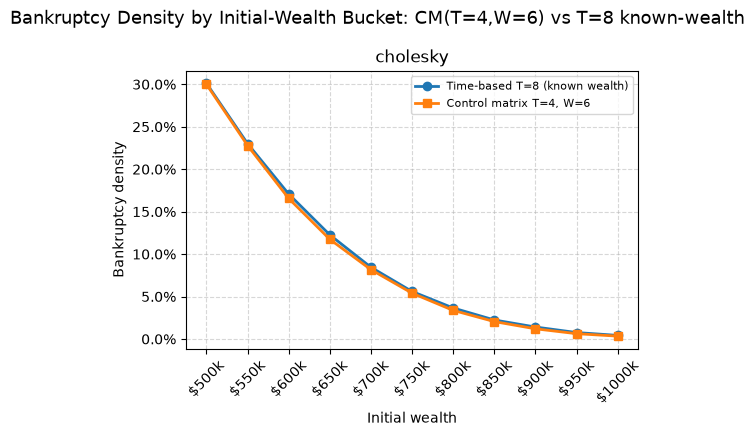

In [ ]:
# Compare bankruptcy density bucket-by-bucket using saved parquet outputs only:
# Control Matrix (T=4, W=6, distributed wealth) vs Time-Based (T=8, known initial wealth)
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

EXPERIMENTS_PARQUET = "./Results/optimisation_experiments.parquet"
OUTCOMES_PARQUET = "./Results/optimisation_outcomes.parquet"

experiment_df = pl.read_parquet(EXPERIMENTS_PARQUET)
outcomes_df = pl.read_parquet(OUTCOMES_PARQUET)

joined = outcomes_df.join(
    experiment_df.select([
        "experiment_file",
        "initial_wealth",
        "n_time_nodes",
        "n_wealth_nodes",
        "sampler",
    ]),
    on="experiment_file",
    how="inner",
)

# Time-based baseline: T=8, W=1, known initial wealth.
t8_known = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 6)
        & (pl.col("n_wealth_nodes") == 1)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "simulated_initial_wealth"])
    .agg(
        pl.col("bankruptcy_density").mean().alias("bankruptcy_density_t8_known")
    )
)

# Control matrix comparison: T=4, W=6, distributed initial wealth (initial_wealth is null).
cm_t4_w6 = (
    joined
    .filter(
        (pl.col("n_time_nodes") == 4)
        & (pl.col("n_wealth_nodes") == 6)
        & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "simulated_initial_wealth"])
    .agg(
        pl.col("bankruptcy_density").mean().alias("bankruptcy_density_cm_t4_w6")
    )
)

comparison = (
    t8_known
    .join(cm_t4_w6, on=["sampler", "simulated_initial_wealth"], how="inner")
    .with_columns(
        (pl.col("bankruptcy_density_cm_t4_w6") - pl.col("bankruptcy_density_t8_known")).alias("delta_cm_minus_t8")
    )
    .sort(["sampler", "simulated_initial_wealth"])
)

if comparison.height == 0:
    raise RuntimeError(
        "No overlapping rows found in parquet data for T=4,W=6 control-matrix and T=8,W=1 known-wealth runs. "
        "Check that wrangling includes control-matrix result archives."
    )

# Console summary.
print("Comparison rows (delta < 0 means control matrix has LOWER bankruptcy density):")
for r in comparison.iter_rows(named=True):
    print(
        f"{r['sampler']:>22} | W0=${r['simulated_initial_wealth']:,.0f} | "
        f"T8={r['bankruptcy_density_t8_known']:.4%} | "
        f"CM(4,6)={r['bankruptcy_density_cm_t4_w6']:.4%} | "
        f"Delta={r['delta_cm_minus_t8']:+.4%}"
    )

# Plot: one panel per sampler, both lines vary by initial wealth bucket.
samplers_present = comparison.select("sampler").unique().sort("sampler")["sampler"].to_list()
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(samplers_present),
    figsize=(5.6 * len(samplers_present), 4.4),
    squeeze=False,
)

for idx, sampler in enumerate(samplers_present):
    ax = axes[0, idx]
    rows = comparison.filter(pl.col("sampler") == sampler).sort("simulated_initial_wealth")

    x = np.array(rows["simulated_initial_wealth"].to_list(), dtype=float)
    y_t8 = np.array(rows["bankruptcy_density_t8_known"].to_list(), dtype=float)
    y_cm = np.array(rows["bankruptcy_density_cm_t4_w6"].to_list(), dtype=float)

    ax.plot(x, y_t8, marker="o", linewidth=2, label="Time-based T=8 (known wealth)")
    ax.plot(x, y_cm, marker="s", linewidth=2, label="Control matrix T=4, W=6")

    ax.set_title(sampler)
    ax.set_xlabel("Initial wealth")
    if idx == 0:
        ax.set_ylabel("Bankruptcy density")

    ax.set_xticks(x)
    ax.set_xticklabels([f"${v/1000:.0f}k" for v in x], rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.grid(linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle("Bankruptcy Density by Initial-Wealth Bucket: CM(T=4,W=6) vs T=8 known-wealth", fontsize=13)
fig.tight_layout()
plt.show()

In [13]:

t8_known

sampler,simulated_initial_wealth,bankruptcy_density_t8_known
str,f64,f64
"""block_bootstrapped_1950""",500000.0,0.224394
"""block_bootstrapped""",600000.0,0.135279
"""cholesky""",950000.0,0.007552
"""block_bootstrapped""",500000.0,0.240535
"""block_bootstrapped_1950""",650000.0,0.081427
…,…,…
"""cholesky""",500000.0,0.300998
"""block_bootstrapped""",550000.0,0.180003
"""block_bootstrapped_1950""",550000.0,0.165406


In [14]:
cm_t4_w6


sampler,simulated_initial_wealth,bankruptcy_density_cm_t4_w6
str,f64,f64


In [17]:
(
    joined
    .filter(
        (pl.col("n_time_nodes") > 1)
        & (pl.col("n_wealth_nodes") > 1)
        # & (pl.col("initial_wealth").is_null())
    )
    .group_by(["sampler", "simulated_initial_wealth"])
    .agg(
        pl.col("bankruptcy_density").mean().alias("bankruptcy_density_cm_t4_w6")
    )
)

sampler,simulated_initial_wealth,bankruptcy_density_cm_t4_w6
str,f64,f64
